# N-spline unfolding method (`unfold_nspline`)

Implementation of the neutron spectrum unfolding approach of

> R. F. Islamgulov, V. D. Lartsev, *Reconstruction of neutron spectra
> from activation measurements in the form of N-splines*,
> **Atomic Energy 104(5), 295–302 (2008)** (RFNC-VNIITF).

The sought spectrum is parameterised by a specialised *neutron spline*
(N-spline) with basis functions

$$N_k(E) = \exp(a_k + q_k \ln E + r_k E), \qquad E_k \le E \le E_{k+1}$$

whose logarithm is linear in both $\ln E$ and $E$. This family contains
$1/E$, Maxwellian evaporation $\exp(-E/T)$ and fission-like
$\sqrt{E}\,e^{-bE}$ spectra as particular members, so the basis is close
to complete while using only $3M$ parameters ($M$ = number of segments).

The activation equations $Q_i = \int \sigma_i(E)\,\varphi(E)\,dE$ are solved
by the **directed divergence minimisation** loop (MIRD): the functional

$$H = \sum_i \left[pN_i \ln \frac{pN_i}{p_i} - pN_i + p_i\right] \ge 0$$

(measured $p_i$ vs calculated $pN_i$, both normalised) is decreased by a
flux-conserving gradient iteration, and the spectrum is **re-fitted by the
N-spline after every iteration** — the paper's regularisation, which makes
the loop act on $3M$ spline parameters instead of $n$ bin values.

Quality control follows the paper: iterations stop when $H$ reaches the
measurement-error level or stalls, and the reconstruction is accepted when

$$nev = \sqrt{\frac{1}{N-1}\sum_i \left(\frac{Qr_i - Q_i}{\Delta Q_i}\right)^2}
\;\le\; 1 + \frac{2}{\sqrt{N}}.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bssunfold import Detector
from bssunfold.core import NSPLINE_KNOT_PRESETS

## 1. Setup — detector and synthetic ground truth

We synthesise detector readings from a known fission-like spectrum
(Watt shape + epithermal $1/E$ tail) folded through the built-in GSF
response functions, then add 5% Gaussian noise. The ground truth stays
hidden from the unfolding procedures and is used afterwards to assess
the reconstruction quality.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from bssunfold import Detector

rng = np.random.default_rng(7)

detector = Detector()
E = detector.E_MeV
names = detector.detector_names
A = np.array([detector.sensitivities[nm] for nm in names])

# ground-truth spectrum (Watt fission + 1/E epithermal tail)
phi_true = np.exp(-E / 1.025) * np.sinh(np.sqrt(2.926 * E))
phi_true += 0.05 / np.maximum(E, 1e-9)
phi_true /= A.sum(axis=0).dot(phi_true)

readings = {nm: float(A[i] @ phi_true) for i, nm in enumerate(names)}
readings_noisy = {
    nm: val * (1 + rng.normal(0, 0.05)) for nm, val in readings.items()
}

print("Detectors:", names)
for nm in names:
    print(f"  {nm:>5s}: {readings_noisy[nm]:.4g}")


Detectors: ['0in', '2in', '3in', '5in', '6in', '8in', '10in', '12in', '15in', '18in']
    0in: 0.5253
    2in: 0.1991
    3in: 0.131
    5in: 0.06279
    6in: 0.04775
    8in: 0.01945
   10in: 0.007851
   12in: 0.002425
   15in: 0.0004647
   18in: 0.0001053


## 2. Unfold with the N-spline method

The paper stresses that a good initial approximation matters (at VNIITF
it was produced by Monte-Carlo calculations). Here we start from a flat
spectrum and use the **BARS-5 channel knot set** from the paper.
The result dictionary carries the paper's diagnostics:
`H`, `H_history`, `H_target`, `nev`, `nev_limit`, `acceptable`.

> **Note on `nev`.** The statistic $nev$ uses *unweighted* relative
> residuals $(Qr_i-Q_i)/\Delta Q_i$. With Bonner-sphere readings that span
> ~8 orders of magnitude, the weakest sphere contributes little to $H$
> (which works with normalised activations) but the same relative weight
> in $nev$ — exactly as in the paper. In the paper's activation-foil
> applications all $Q_i$ are comparable and $nev \approx 1$
> (see Tables 1–2 of the paper).

In [3]:
result = detector.unfold_nspline(
    readings_noisy,
    knots="BARS5_channel",       # knot preset from the paper
    relative_uncertainty=0.05,   # dQ/Q used by the stopping criteria
    max_iterations=300,
    save_result=False,
)

print(f"method        : {result['method']}")
print(f"iterations    : {result['iterations']}  ({result['stop_reason']})")
print(f"H             : {result['H']:.3e}  (target {result['H_target']:.3e})")
print(f"nev           : {result['nev']:.3f}  (limit {result['nev_limit']:.3f})")
print(f"acceptable    : {result['acceptable']}")
print(f"fluence       : {result['fluence']:.4g}")
print(f"mean energy   : {result['mean_energy']:.4g} MeV")
print("knots (MeV)   : " + ", ".join(f"{k:.2e}" for k in result["knots"]))


method        : NSPLINE
iterations    : 224  (H_target)
H             : 1.239e-03  (target 1.250e-03)
nev           : 30.611  (limit 1.632)
acceptable    : False
fluence       : 5.819
mean energy   : 114.4 MeV
knots (MeV)   : 1.00e-09, 1.30e-07, 3.83e-07, 8.00e-06, 2.00e-05, 3.00e-05, 7.30e-05, 3.20e-03, 3.80e-01, 9.50e-01, 7.00e+00, 1.70e+01, 6.31e+02


## 3. Comparison with GRAVEL and iteration diagnostics

GRAVEL (weighted log-least-squares) is the widely used reference method
for activation/Bonner-sphere unfolding. We compare the recovered shapes
(normalised) on the energy range where the ground truth is significant,
inspect the decrease of $H$, and the relative residuals
$(Qr_i - Q_i)/\Delta Q_i$ — the paper's Fig. 2 analogue.

> **Note on the spectrum tail.** The GSF grid extends to ~600 MeV, where
> Bonner spheres are blind. There the reconstruction is prior-driven
> (C0/C1-continuation of the spline), so `fluence` and `mean_energy`
> diagnostics over the full grid should be interpreted with care;
> the spectral shape on the sensitive range is what the method recovers.

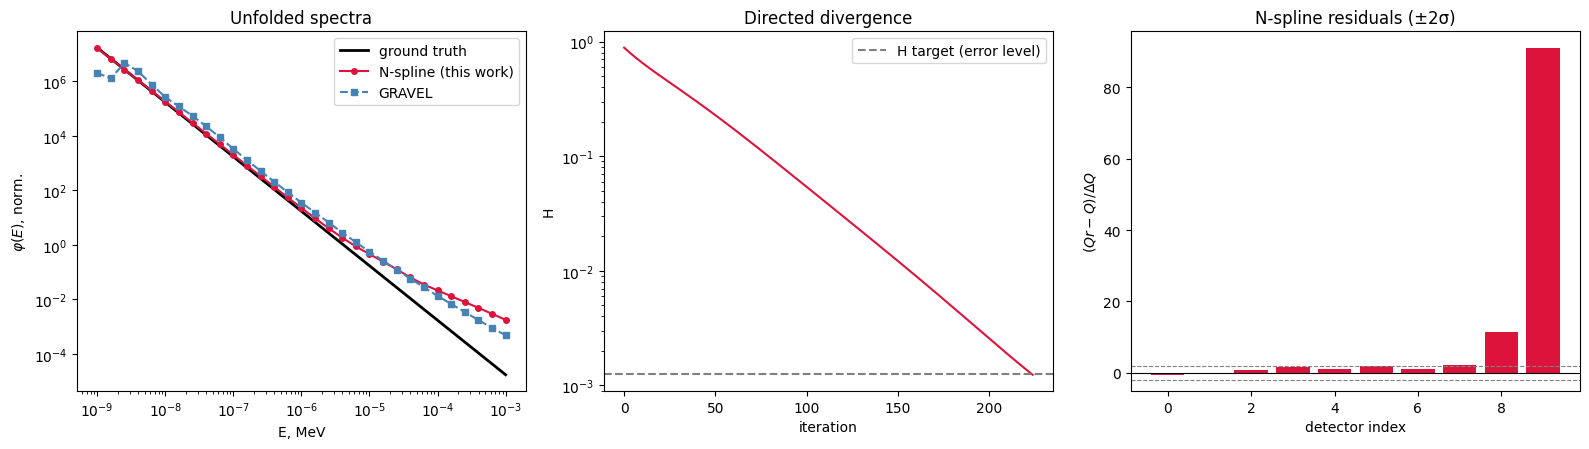

median |log10 deviation| — N-spline: 0.119 dex, GRAVEL: 0.386 dex


In [4]:
grav = detector.unfold_gravel(
    readings_noisy,
    initial_spectrum=np.full(E.size, 0.5),
    max_iterations=2000,
    save_result=False,
)

def norm(spec):
    return spec / spec.sum()

sig = phi_true > 1e-6 * phi_true.max()          # significant-truth range
scale_true = phi_true.sum()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
ax.loglog(E[sig], norm(phi_true)[sig] / (E[sig] * scale_true), "k-",
          label="ground truth", lw=2)
ax.loglog(E[sig], norm(result["spectrum"])[sig] / (E[sig] * scale_true),
          "o-", color="crimson", ms=4, label="N-spline (this work)")
ax.loglog(E[sig], norm(grav["spectrum"])[sig] / (E[sig] * scale_true),
          "s--", color="steelblue", ms=4, label="GRAVEL")
ax.set(xlabel="E, MeV", ylabel=r"$\varphi(E)$, norm.",
       title="Unfolded spectra")
ax.legend()

ax = axes[1]
ax.semilogy(result["H_history"], color="crimson")
ax.axhline(result["H_target"], ls="--", color="gray",
           label="H target (error level)")
ax.set(xlabel="iteration", ylabel="H", title="Directed divergence")
ax.legend()

qr = result["Qr"]
b = np.array([readings_noisy[nm] for nm in names])
sigma = 0.05 * b
axes[2].bar(np.arange(len(b)), (qr - b) / sigma, color="crimson")
axes[2].axhline(0, color="k", lw=0.8)
for k in (2, -2):
    axes[2].axhline(k, ls="--", color="gray", lw=0.8)
axes[2].set(xlabel="detector index", ylabel="$(Qr-Q)/\\Delta Q$",
            title="N-spline residuals (±2σ)")
fig.tight_layout()
plt.show()

dev_ns = np.median(np.abs(np.log10(norm(result["spectrum"])[sig]
                                    / norm(phi_true)[sig])))
dev_gr = np.median(np.abs(np.log10(norm(grav["spectrum"])[sig]
                                    / norm(phi_true)[sig])))
print(f"median |log10 deviation| — N-spline: {dev_ns:.3f} dex, "
      f"GRAVEL: {dev_gr:.3f} dex")


## 4. Knot presets and options

The knot sets used in the paper for the BARS-5, IGRIK and YAGUAR
reactors are shipped as presets; an automatic log-uniform grid is also
available (default), as well as explicitly user-supplied knots.
`continuity="C0"` keeps only the value continuity (first block row of
the matrix $D$), `smoothing=False` disables the per-iteration N-spline
refit and reduces the loop to the plain MIRD iteration.

In [5]:
from bssunfold.core import NSPLINE_KNOT_PRESETS

for name, knots in NSPLINE_KNOT_PRESETS.items():
    print(f"{name:>16s}: {len(knots)} knots, "
          f"{knots[0]:.1e} .. {knots[-1]:.0f} MeV")

rows = []
for label, kwargs in [
    ("auto knots", dict()),
    ("BARS5_channel", dict(knots="BARS5_channel")),
    ("IGRIK_channel", dict(knots="IGRIK_channel")),
    ("YAGUAR_channel", dict(knots="YAGUAR_channel")),
    ("C0 only", dict(continuity="C0")),
    ("no smoothing (plain MIRD)", dict(smoothing=False)),
]:
    res = detector.unfold_nspline(readings_noisy,
                                  relative_uncertainty=0.05,
                                  max_iterations=300,
                                  save_result=False, **kwargs)
    dev = np.median(np.abs(np.log10(norm(res["spectrum"])[sig]
                                    / norm(phi_true)[sig])))
    rows.append((label, res["iterations"], res["nev"], res["acceptable"],
                 res["fluence"], res["mean_energy"], dev))

print(f"{'variant':>26s} | {'iters':>5s} | {'nev':>6s} | {'ok?':>5s} | "
      f"{'fluence':>8s} | {'E_mean':>7s} | {'median dev, dex':>15s}")
for label, it, nev, ok, flu, eme, dev in rows:
    print(f"{label:>26s} | {it:5d} | {nev:6.2f} | {str(ok):>5s} | "
          f"{flu:8.3g} | {eme:7.3g} | {dev:15.3f}")


   BARS5_channel: 13 knots, 1.0e-10 .. 20 MeV
   IGRIK_channel: 17 knots, 1.0e-10 .. 20 MeV
   IGRIK_surface: 15 knots, 1.0e-10 .. 20 MeV
  YAGUAR_channel: 19 knots, 1.0e-10 .. 20 MeV


                   variant | iters |    nev |   ok? |  fluence |  E_mean | median dev, dex
                auto knots |   300 | 136.08 | False |     8.81 |    80.1 |           0.103
             BARS5_channel |   224 |  30.61 | False |     5.82 |     114 |           0.119
             IGRIK_channel |   300 |  63.11 | False | 1.18e+03 |     227 |           0.182
            YAGUAR_channel |   223 |  27.13 | False |     3.43 |    99.9 |           0.138
                   C0 only |   171 |  89.10 | False | 5.36e+10 |     631 |           7.040
 no smoothing (plain MIRD) |   281 |  29.63 | False |      217 |     374 |           0.421
